# Do Monetary Policy Instruments Predict Inflation  in Kenya?
### An emprical analysis using ARDL Bounds Testing (2013-2026)
**Author:** Ian Kiarie Murega 
**Date:** 10th june 2026
** DATA Source:** Central Bank of Kenya (CBK)

## Project Overview
This notebook investigates whether CBK monetary policy instruments predict kenya's monthly headline inflation.
** Research Question:**
> Do interest rate decisions by CBK actually control inflation?
** Data Files Used:**
-inflation rates (KNBS)
-central Bank Rate (CBK)
-Treasury Bills Average Rates (CBK)
-Trade Weighted Exchange Rates (CBK)

## 1. Library Imports
we import the following libraries:
-**Pandas & Numpy **- data manipulation and computation
-**Matplotlib**-visualisation of time series trends
-**OS** -file path management for loading CBK data files
-**Statsmodels**-econometrics models (OLS, ADF,ARDL,Granger)
-**Sklearn**-baseline machine learning models(OLS,Lasso)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

### Libraries Loaded successfully
**NEXT step:** Load and explore the raw CBK and KNBS data files

In [12]:
path=r'C:\Users\Administrator\Downloads\kenya_inflation_project\cbk_data'
files=os.listdir(path)
for i , f in enumerate(files):
    print(i,repr(f))

0 '1637145009_Inflation Rates.csv'
1 'Central Bank Rate (CBR) .csv'
2 'TRADE WEIGHTED AVERAGE INDICATIVE RATES(1).csv'
3 'Treasury Bills Average Rates.csv'


## Data Loading & Overview
## variables

In [14]:
inflation=pd.read_csv(os.path.join(path,files[0]))
cbr=pd.read_csv(os.path.join(path,files[1]))
forex=pd.read_csv(os.path.join(path,files[2]))
tbills=pd.read_csv(os.path.join(path,files[3]))
print("Inflation:",inflation.shape)
print("CBR:",cbr.shape)
print("FOREX:",forex.shape)
print("T-bills:",tbills.shape)

Inflation: (258, 4)
CBR: (122, 2)
FOREX: (600, 3)
T-bills: (4112, 4)


### RAW DATASET SIZES
- inflation 258 rows and 4 columns
- CBR 122 rows and 2 columns
- FOREX 600 rows and 3 columns
- T-bills 4112 rows and 4 columns

In [15]:
print('====Inflation===')
print(inflation.head())
print(inflation.columns.tolist())

====Inflation===
   Unnamed: 0 Unnamed: 1  Inflation (month-on-month) %  \
0      2005.0        Jan                         14.87   
1         NaN        Feb                         13.94   
2         NaN        Mar                         14.15   
3         NaN        Apr                         16.02   
4         NaN        May                         14.78   

   Inflation (annual average) %  
0                         12.27  
1                         12.60  
2                         13.07  
3                         13.76  
4                         14.61  
['Unnamed: 0', 'Unnamed: 1', 'Inflation (month-on-month) %', 'Inflation (annual average) %']


## inflation Raw Columns
-Unnamed:0-year(with NAN gaps)
-Unnamed:1-month name
-inflation (month on month)% -Mom rate
-inflation(annual average)%- annual rate
**Note:** Raw data is messy column names  and NAN values in the year column- these will be handled in data cleaning
-data start as **2005** but we will filter to **2013-2026** for modelling consistency.

In [16]:
print('====CBR===')
print(cbr.head())
print(cbr.columns.tolist())

====CBR===
         Date  Rate
0  10/02/2026  8.75
1  10/02/2026  8.75
2  09/12/2025  9.00
3  07/10/2025  9.25
4  12/08/2025  9.50
['Date', 'Rate']


**NOTE ** CBR is recorded at decision dates  not monthly  each rate applies from its decision date until the next  decision .We will convert this to monthly  frequency

In [17]:
print('====FOREX===')
print(forex.head())
print(forex.columns.tolist())

====FOREX===
         Date   Currency  EXCHANGE RATE
0  05/06/2026  US DOLLAR         129.32
1  04/06/2026  US DOLLAR         129.37
2  03/06/2026  US DOLLAR         129.45
3  02/06/2026  US DOLLAR         129.45
4  29/05/2026  US DOLLAR         129.55
['Date', 'Currency', 'EXCHANGE RATE']


In [18]:
print('====T-Bills===')
print(tbills.head())
print(tbills.columns.tolist())

====T-Bills===
   Issue Date  Issue No  Tenor  Weighted Average Rate
0  08/06/2026      2614    364                 8.7629
1  08/06/2026      2659    182                 8.5252
2  08/06/2026      2685     91                 8.5588
3  01/06/2026      2613    364                 8.6266
4  01/06/2026      2658    182                 8.2500
['Issue Date', 'Issue No', 'Tenor', 'Weighted Average Rate']


**Note:** T_bills are issued weekly with  three tenors (91,182,364 days).we will pivot and aggregate to monthly averages per tenor

In [34]:
print(inflation.columns.tolist())

['year', 'Month', 'Inflation_Mom', 'Inflatio_ Annual', 'Date']


## Data Cleaning
-Ensuring date format, sorting, and handling missing values.

### Inflation DATA cleaning steps
**Column remaining** standardized to ['year,month,inflation_Mom, inflation_Annual,date]
**year forward-fill**-year column had NaN gaps only the first row of each year had a value
**date column** constructed from year +month for time series alingnment
**inflation_mom interpolitation** filled any missing monthly values using linear interpolation

In [35]:
inflation.columns=[
    'year',
    'Month',
    'Inflation_Mom',
    'Inflation_Annual',
    'Date'
]

In [36]:
inflation["year"]=(
    inflation["year"].ffill()
)
inflation=inflation.dropna(
    subset=["Month"]
)
inflation["Inflation_Mom"]=(
    inflation["Inflation_Mom"]
    .interpolate(method="linear")
)
print("missing values after cleaning:")
print(inflation.isnull().sum())
print(inflation.head(15))
print("shape:",inflation.shape)

missing values after cleaning:
year                0
Month               0
Inflation_Mom       0
Inflation_Annual    1
Date                5
dtype: int64
      year Month  Inflation_Mom  Inflation_Annual       Date
0   2005.0   Jan          14.87             12.27 2005-01-01
1   2005.0   Feb          13.94             12.60 2005-02-01
2   2005.0   Mar          14.15             13.07 2005-03-01
3   2005.0   Apr          16.02             13.76 2005-04-01
4   2005.0   May          14.78             14.61 2005-05-01
5   2005.0   Jun          11.92             15.10 2005-06-01
6   2005.0   Jul          11.76             15.34 2005-07-01
7   2005.0   Aug           6.87             14.53 2005-08-01
8   2005.0   Sep           4.27             13.24 2005-09-01
9   2005.0   Oct           3.72             11.99 2005-10-01
10  2005.0   Nov           4.40             10.89 2005-11-01
11  2005.0   Dec           4.70              9.87 2005-12-01
12  2006.0   Jan           8.39              9.36 200

**shape** (258,5) -data from 2005 to 2026
**sample(2005 data):**
inflation shows kenya experienced a high inflation  in 2005
we filter to 2013 0nwards for modelling

In [37]:
inflation_clean=inflation[
    (inflation["Date"]>= "2013-01-01")&
    (inflation['Date']<= "2026-06-30")
    ].reset_index(drop=True)
inflation_clean=inflation_clean[['Date', 'Inflation_Mom']].copy()
inflation_clean.columns =['date', 'inflation']
print("Shape:", inflation_clean.shape)
print("Start:", inflation_clean['date'].min())
print("End:", inflation_clean['date'].max())
print(inflation_clean.head())

Shape: (159, 2)
Start: 2013-01-01 00:00:00
End: 2026-05-01 00:00:00
        date  inflation
0 2013-01-01       3.67
1 2013-02-01       4.45
2 2013-03-01       4.11
3 2013-04-01       4.14
4 2013-05-01       4.05


 **WHY 2013?**
 -CBR data is more consistent  from 2013

In [40]:
cbr.columns =['date','cbr_rate']
cbr['date']=pd.to_datetime(
    cbr['date'],
    dayfirst=True,
    errors='coerce'
)

In [41]:
print(cbr.head(5))
print(cbr.shape)
print(cbr.dtypes)
print(cbr.isnull().sum())

        date  cbr_rate
0 2026-02-10      8.75
1 2026-02-10      8.75
2 2025-12-09      9.00
3 2025-10-07      9.25
4 2025-08-12      9.50
(122, 2)
date        datetime64[ns]
cbr_rate           float64
dtype: object
date        0
cbr_rate    0
dtype: int64


### CBR RATE Data CLEANING
**Steps:**
1.Renamed columns to ['date','cbr_rate']
2. Converted date to datetime with dayfirst=True
3.Converted to monthly period using  .dt.to_period ('M')
4.Grouped by month and took the **mean**(some months had 2 rate decisions)
5.Filtered from 2013-01-01 onwards
**shape** (84,2)
**Note** CBK does not change the CBR every month- rate stays constant until next Monetary Policy Committee (MPC) decision.Monthly groupby captures the effective rate for each month

In [42]:
cbr.columns= ['date','cbr_rate']
cbr['date']=(cbr['date']
    .dt.to_period('M')
    .dt.to_timestamp()
            )
cbr_clean =(cbr
    .groupby('date')['cbr_rate']
    .mean()
    .reset_index()
           )
cbr_clean =cbr_clean[
    cbr_clean['date'] >='2013-01-01'].reset_index(drop=True)
print("shape:",cbr_clean.shape)
print(cbr_clean.head())

shape: (84, 2)
        date  cbr_rate
0 2013-01-01       9.5
1 2013-03-01       9.5
2 2013-05-01       8.5
3 2013-07-01       8.5
4 2013-09-01       8.5


### T-Bills Data Cleaning
**Steps:**
1.Renamed to [date, issue_no, tenor,rate]
2.Converted date using pd.to_datetime with dayfirst=True,errors='coerce'
3.Converted to monthly period
4.Will pivot by tenor to get 3 separate columns

In [51]:
tbills.columns =['date','issue_no','tenor','rate']
tbills['date']=pd.to_datetime(
    tbills['date'],
    dayfirst=True,
    errors='coerce'
)

In [52]:
print(tbills.head(5))
print(tbills.shape)
print(tbills.dtypes)
print(tbills.isnull().sum())

        date  issue_no  tenor    rate
0 2026-06-08      2614    364  8.7629
1 2026-06-08      2659    182  8.5252
2 2026-06-08      2685     91  8.5588
3 2026-06-01      2613    364  8.6266
4 2026-06-01      2658    182  8.2500
(4112, 4)
date        datetime64[ns]
issue_no             int64
tenor                int64
rate               float64
dtype: object
date        0
issue_no    0
tenor       0
rate        0
dtype: int64


## T-Bills pivot to Monthly Format
**Transformation steps:**
1.convert date to monthly period
2.Group by [date, tenor] and take  mean rate
3.Unstack tenor to create wide format
4.Rename Columns to [date, tbill_91,tbill_182,tbill_363]
5.filter from 2013-01-01

In [56]:
print(tbills_pivot.columns.tolist())
print(tbills_pivot.shape)

['date', 'tenor', 'rate']
(840, 3)


In [57]:
tbills.columns= ['date','issue_no','tenor','rate']
tbills['date']=(tbills['date']
    .dt.to_period('M')
    .dt.to_timestamp()
            )
tbills_pivot =(tbills
    .groupby(['date','tenor'])['rate']
    .mean()
    .unstack('tenor')
    .reset_index()
           )
tbills_pivot.columns = [
    'date', 'tbill_91','tbill_182','tbill_364']
tbills_clean =tbills_pivot[
    tbills_pivot['date'] >='2013-01-01'].reset_index(drop=True)
print("shape:",tbills_clean.shape)
print(tbills_clean.head())

shape: (162, 4)
        date   tbill_91  tbill_182  tbill_364
0 2013-01-01   8.088222    8.08675  11.670000
1 2013-02-01   8.534000    8.39700  11.662000
2 2013-03-01  10.019875    9.89125  12.543250
3 2013-04-01  10.342700   10.75260  12.492600
4 2013-05-01   9.370571   10.04450  11.079889


### USD/KES Exchange Rate Data
**Source:** Yahoo finance  via yfinance  library
**ticker** KES=X(USD to KES)
**Period :** 2013-01-01 to 2026-06-01
**interval:** monthly
**steps:**
1.Downloaded monthly closing price using 'yf.download()
2.Extracted Close column
3.Renamed to ['date, usd_kes]
4.Converted to monthly period timestamp

**Result shape:** (161,2)




In [48]:
import yfinance as yf

In [50]:
usdkes=yf.download(
    'KES=X',
    start='2013-01-01',
    end='2026-06-01',
    interval='1mo',
    progress=False
)
usdkes=usdkes[['Close']].reset_index()
usdkes.columns=['date','usd_kes']
usdkes['date']=pd.to_datetime(
    usdkes['date']).dt.to_period('M').dt.to_timestamp()
print('shape:',usdkes.shape)
print(usdkes.head())


shape: (161, 2)
        date    usd_kes
0 2013-01-01  86.176003
1 2013-02-01  84.712997
2 2013-03-01  83.891998
3 2013-04-01  82.278999
4 2013-05-01  83.973000


**observation:** KES was 86 per USD in jan 2013. by 2026 it reached 128-129,showing significant shilling depreciation over 13 yrs -a **50% depreciation** in the modelling period

## Merging All Datasets into Master DataFrame
all four cleaned datasets are merged on the date column using **outer joins** to preserve all records.

In [59]:
master=inflation_clean.merge(
    cbr_clean,on='date',how='outer').merge(tbills_clean,on='date',how='outer').merge(usdkes,on='date',how='outer')
master=master.sort_values('date').reset_index(drop=True)
master=master[(master['date']>='2013-01-01')&(master['date']<='2026-06-30')]
print('shape:',master.shape)
print('Columns:',master.columns.tolist())
print(master.isnull().sum())
print(master.head())
print(master.tail())
    

shape: (162, 7)
Columns: ['date', 'inflation', 'cbr_rate', 'tbill_91', 'tbill_182', 'tbill_364', 'usd_kes']
date          0
inflation     3
cbr_rate     78
tbill_91      0
tbill_182     1
tbill_364     0
usd_kes       1
dtype: int64
        date  inflation  cbr_rate   tbill_91  tbill_182  tbill_364    usd_kes
0 2013-01-01       3.67       9.5   8.088222    8.08675  11.670000  86.176003
1 2013-02-01       4.45       NaN   8.534000    8.39700  11.662000  84.712997
2 2013-03-01       4.11       9.5  10.019875    9.89125  12.543250  83.891998
3 2013-04-01       4.14       NaN  10.342700   10.75260  12.492600  82.278999
4 2013-05-01       4.05       8.5   9.370571   10.04450  11.079889  83.973000
          date  inflation  cbr_rate  tbill_91  tbill_182  tbill_364  \
157 2026-02-01       4.25      8.75  7.615425   7.777050   9.070750   
158 2026-03-01       4.39       NaN  7.543420   7.827280   8.507840   
159 2026-04-01       5.59       NaN  7.500875   7.843875   8.272825   
160 2026-05-01 

**After merge**
-shape:**(162,7)**
-columns: [date,inflation,cbr_rate,tbill_91,tbill_182,tbill364, usd_kes]
-date range: 2013-01-01 to 2026-06-30
3 CBR months without inflation
78 CBR not recorded every month**NOTE** cbr_rate has 78 missing because CBK only changes rates -6-8 times per year-gaps are forward-filled in the next step.
tbill_182 one missing auction month
usd_kes-one missing forex month

In [63]:
master['cbr_rate']=master['cbr_rate'].ffill()
master['cbr_rate']=master['cbr_rate'].bfill()
cols=['inflation','tbill_182','usd_kes']
for col in cols:
    master[col]=master[col].interpolate(method='linear')
master=master.dropna().reset_index(drop=True)

print('shape:',master.shape)
print(master.isnull().sum())
print(master.head())


shape: (162, 7)
date         0
inflation    0
cbr_rate     0
tbill_91     0
tbill_182    0
tbill_364    0
usd_kes      0
dtype: int64
        date  inflation  cbr_rate   tbill_91  tbill_182  tbill_364    usd_kes
0 2013-01-01       3.67       9.5   8.088222    8.08675  11.670000  86.176003
1 2013-02-01       4.45       9.5   8.534000    8.39700  11.662000  84.712997
2 2013-03-01       4.11       9.5  10.019875    9.89125  12.543250  83.891998
3 2013-04-01       4.14       9.5  10.342700   10.75260  12.492600  82.278999
4 2013-05-01       4.05       8.5   9.370571   10.04450  11.079889  83.973000


## FInal Master Dataset- AfterFilling
**Handling missing values:**
-cbr_rate -forward-filled (ffill)-rate stays the same until next MPC decision
-inflation -drop 3 rows  with missing values
-tbill_182, usd_kes -interpolated linearly 
**final master shape:** (162,7)-**no missing values**
**Data is clean and ready for EDA and modelling!**
**Period covered:** jan 2013-may2026
**Total obsevations**162 monthly records
**Variables:** 6 macroeconomic indicators

In [64]:
master.head(10)

,date,inflation,cbr_rate,tbill_91,tbill_182,tbill_364,usd_kes
0,2013-01-01,3.67,9.5,8.088222,8.086750,11.670000,86.176003
1,2013-02-01,4.45,9.5,8.534000,8.397000,11.662000,84.712997
2,2013-03-01,4.11,9.5,10.019875,9.891250,12.543250,83.891998
3,2013-04-01,4.14,9.5,10.342700,10.752600,12.492600,82.278999
4,2013-05-01,4.05,8.5,9.370571,10.044500,11.079889,83.973000
5,2013-06-01,4.91,8.5,6.206000,6.949444,8.459000,84.304001
6,2013-07-01,6.03,8.5,5.917200,6.361500,8.814400,86.000000
7,2013-08-01,6.67,8.5,10.030000,9.955143,11.380000,86.105003
8,2013-09-01,8.29,8.5,9.557273,10.149600,10.822000,84.918999
9,2013-10-01,7.76,8.5,9.767714,10.277750,11.930800,83.922997


In [65]:
master.tail()

,date,inflation,cbr_rate,tbill_91,tbill_182,tbill_364,usd_kes
157,2026-02-01,4.25,8.75,7.615425,7.777050,9.070750,128.899994
158,2026-03-01,4.39,8.75,7.543420,7.827280,8.507840,129.289993
159,2026-04-01,5.59,8.75,7.500875,7.843875,8.272825,128.130005
160,2026-05-01,6.68,8.75,8.233350,8.211275,8.544750,128.509995
161,2026-06-01,6.68,8.75,8.473600,8.387600,8.694750,128.509995


In [66]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       162 non-null    datetime64[ns]
 1   inflation  162 non-null    float64       
 2   cbr_rate   162 non-null    float64       
 3   tbill_91   162 non-null    float64       
 4   tbill_182  162 non-null    float64       
 5   tbill_364  162 non-null    float64       
 6   usd_kes    162 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 9.0 KB


In [67]:
master.describe()

,date,inflation,cbr_rate,tbill_91,tbill_182,tbill_364,usd_kes
count,162,162.000000,162.000000,162.000000,162.000000,162.000000,162.000000
mean,2019-09-16 03:42:13.333333248,6.031543,9.280864,9.039109,9.989373,10.888608,108.844317
min,2013-01-01 00:00:00,2.720000,7.000000,5.917200,6.361500,7.434800,82.278999
25%,2016-05-08 18:00:00,4.602500,8.500000,7.325650,8.108462,9.535988,99.599998
50%,2019-09-16 00:00:00,5.855000,9.000000,8.228375,9.808278,10.462440,102.325001
75%,2023-01-24 06:00:00,6.917500,10.000000,9.484567,10.504075,11.145750,125.429998
max,2026-06-01 00:00:00,11.700000,13.000000,21.411222,21.630000,21.796667,160.250000
std,NaN,1.663399,1.580590,2.692228,2.619054,2.347867,17.127094


In [82]:
data_2025=master[
    (master['date'] >='2025-01-01')&
    (master['date']<='2025-12-31')].reset_index(drop=True)
print(data_2025)

         date  inflation  cbr_rate  tbill_91  tbill_182  tbill_364     usd_kes
0  2025-01-01       3.28     11.25  9.627150  10.027250  11.326050  129.000000
1  2025-02-01       3.45     10.75  9.138725   9.567025  10.797875  129.000000
2  2025-03-01       3.62     10.75  8.881720   9.129940  10.468680  127.570000
3  2025-04-01       4.11     10.00  8.510825   9.154825  10.213067  129.000000
4  2025-05-01       3.75     10.00  8.370075   8.594525  10.005100  128.250000
5  2025-06-01       4.01      9.75  8.212120   8.507940   9.841880  128.149994
6  2025-07-01       4.27      9.75  8.133150   8.435000   9.720525  128.500000
7  2025-08-01       4.53      9.50  8.050300   8.193200   9.646650  127.700539
8  2025-09-01       4.58      9.50  7.963680   8.019480   9.553200  129.000000
9  2025-10-01       4.56      9.25  7.875775   7.922275   9.410625  128.199997
10 2025-11-01       4.46      9.25  7.792050   7.821700   9.355525  127.835495
11 2025-12-01       4.49      9.00  7.768220   7.800

## Exploratory Data Analysis (EDA)
## Time Series - Inflation vs CBR rate
-visualizing how inflation and cbr rate moved on the year 2025 and 2026 only
-To understand the most  recent inflation dynamics,
**Why this matters**
-2025-2026 represents the most  current monetary policy environment
-CBK has been actively cutting CBR rate during  this period 
- Help identify the recent trend before modelling

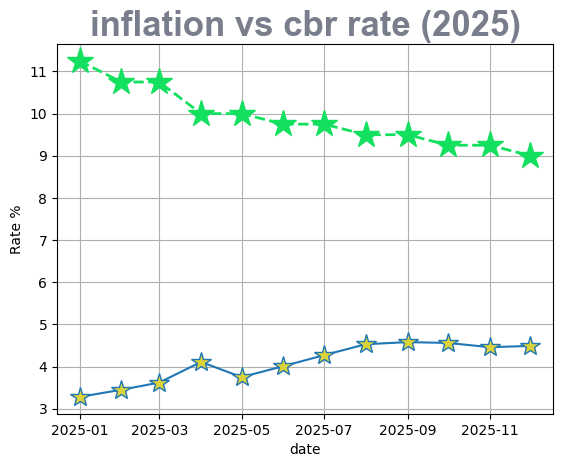

In [83]:
plt.plot(data_2025['date'],data_2025['inflation'],label='inflation',marker='*',markersize=15, markerfacecolor='#dbd339',)
plt.plot(data_2025['date'],data_2025['cbr_rate'],label='cbr_rate',marker='*',markersize=20, markerfacecolor='#14e05f',linestyle='dashed',linewidth=2,color='#14e05f')
plt.title('inflation vs cbr rate (2025)',fontsize=25,fontweight='bold',family='Arial',color='#7a7e8c')
plt.xlabel('date')
plt.ylabel('Rate %')
plt.grid()
plt.show()
                                                                          
                                                                          

**KEY OBSERVATIONS FROM the CHART**
-inflation started at **11%** in early 2025 and declined steadily to **9%** by end of 2025
-CBR rate remained low at an average rate 0f **4%**-**4.5%** through out 2025
-The downward trend in inflation suggests CBK rates cuts were not fuelling further inflation
- inflation was declining despite loose monetary policy

## DATA Preview & TIME series Plot
filtering data for january-May 2026 to analyze  the most recent inflation environment

In [84]:
data_2026=master[
    (master['date'] >='2026-01-01')&
    (master['date']<='2026-05-01')].reset_index(drop=True)
print(data_2026)

        date  inflation  cbr_rate  tbill_91  tbill_182  tbill_364     usd_kes
0 2026-01-01       4.40      9.00  7.721200   7.798350   9.204375  128.070007
1 2026-02-01       4.25      8.75  7.615425   7.777050   9.070750  128.899994
2 2026-03-01       4.39      8.75  7.543420   7.827280   8.507840  129.289993
3 2026-04-01       5.59      8.75  7.500875   7.843875   8.272825  128.130005
4 2026-05-01       6.68      8.75  8.233350   8.211275   8.544750  128.509995


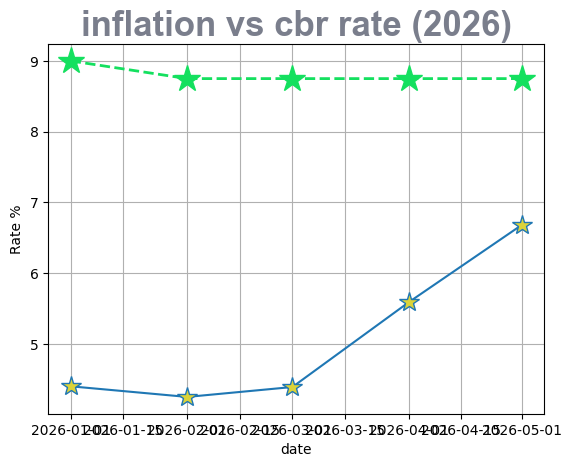

In [85]:
plt.plot(data_2026['date'],data_2026['inflation'],label='inflation',marker='*',markersize=15, markerfacecolor='#dbd339',)
plt.plot(data_2026['date'],data_2026['cbr_rate'],label='cbr_rate',marker='*',markersize=20, markerfacecolor='#14e05f',linestyle='dashed',linewidth=2,color='#14e05f')
plt.title('inflation vs cbr rate (2026)',fontsize=25,fontweight='bold',family='Arial',color='#7a7e8c')
plt.xlabel('date')
plt.ylabel('Rate %')
plt.grid()
plt.show()


### 2026 : inflation Vs CBR Rate
**Key Observations from the chart:**
-CBR rate steady at **8.75-9%**(dashed line,flat)
-inflation  lowest point is averagely at **4.2**-**4.3** but then **sharply rebounded** **to 6.68%** bymay 2026  which is a averagely a **2.4%** and **2.5%** percentage point jump 
**Key finding** The policy environment shifted  dramatically from loose(2025) to tight(2026) CBK rates significantly raised while inflation fell

## correlation Matrix
**reading of correlation matrix**
-values range from -1 to +1
- close to +1 -strong positive  relationship
- close to -1 -strong negative relationship
- close to 0 -weak/no linear relationship

In [72]:
master.corr()

,date,inflation,cbr_rate,tbill_91,tbill_182,tbill_364,usd_kes
date,1.000000,-0.213310,0.098123,0.179046,0.046648,0.013924,0.898282
inflation,-0.213310,1.000000,-0.102766,0.050395,0.092508,-0.004259,-0.058200
cbr_rate,0.098123,-0.102766,1.000000,0.750654,0.810168,0.830697,0.349722
tbill_91,0.179046,0.050395,0.750654,1.000000,0.956956,0.948923,0.462405
tbill_182,0.046648,0.092508,0.810168,0.956956,1.000000,0.972128,0.343490
tbill_364,0.013924,-0.004259,0.830697,0.948923,0.972128,1.000000,0.303169
usd_kes,0.898282,-0.058200,0.349722,0.462405,0.343490,0.303169,1.000000


# Correlation Heatmap
-**key observation** : t-bill rates are highly correlated and  which increases the risk for multicollinearity
-This is why we will use only tbill_364 in the ARDL model to avoid redundancy

# Machine learning  models 
# Data preparation

In [88]:
features=master[['cbr_rate','tbill_91','tbill_182','tbill_364','usd_kes']]

In [102]:
x=features
y=master['inflation']

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [111]:
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [122]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

### linear regression (Baseline Model)
-Assumes a linear relationship between features
*** features (x):** cbr_rate, tbill_91,tbill_182,tbill_364, usd_kes
***Target (y):** inflation

In [123]:
from sklearn.linear_model import LinearRegression

In [124]:
lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
y_pred=lr.predict(x_test_scaled)

In [125]:
from sklearn.metrics import mean_squared_error,r2_score


In [166]:
print('R2 Score:', r2_score(y_test,y_pred))
print('RMSE:',mean_squared_error(y_test,y_pred))
print('===linear regression=')

R2 Score: 0.04377228472154604
RMSE: 2.38000881116573
===linear regression=


### Linear Regeression Results
R2 score -0.0438
RMSE-2.38
** Interpretation:**
-R2 score of 0.0438 means  the model explains only **4.38%** of the variation in inflation
-RMSE of 2.38 means prediction is off by +_2.38percentage points
- This is a **weak model**-inflation is not well explained by these variables
- This motivates trying regularization models (Lasso) and more advanced econometrics approaches

## Lasso Regression (alpha=0.1)
Lasso adds penaity to shrink less important coefficients  to zero reducing overfitting and handling muiticollinearity between t-BILL RATES
-**alpha=0.1** - moderate regularization strength

In [136]:
r=Lasso(alpha=0.1)
r.fit(x_train_scaled,y_train)
y_pred=r.predict(x_test_scaled)

In [137]:
print('R2 Score:', r2_score(y_test,y_pred))
print('RMSE:',mean_squared_error(y_test,y_pred))
print('==LASSO 1==')

R2 Score: 0.04377228472154604
RMSE: 2.38000881116573
==LASSO 1==


### Lasso (alpha=0.1) Results
R2 score - 0.0438
RMSE -2.38
**Interpretation:**
-Same results as Linear Regression-regularization had no significant effect at alpha=0.1
-Suggests the problems is not overfitting but the features have weak linear relationship

### Lasso Regression (alpha=0.001)
Testing a very small penalty -closer to plain linear regression
lower alpha=less shrinkage= more coefficients retained

In [132]:
r=Lasso(alpha=0.001)
r.fit(x_train_scaled,y_train)
y_pred=r.predict(x_test_scaled)

In [167]:
print("R2 Score:",r2_score(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred))
print('=== LASSO 2 RESULTs===')

R2 Score: 0.04377228472154604
RMSE: 2.38000881116573
=== LASSO 2 RESULTs===


### Lasso (alpha=0.001) Results
R2score - 0.0438
RMSE 2.38
**Overall ML Observation:**
-All three models (Linear Regression, Lasso alpha=0.1,Lasso alpha=0.001)
produced **identical results**-R2=0.0438,RMSE=2.38
-This strongly suggests the**relationship between these monetary policy variables and inflation has negative linearity**
-Next step: **econometric models** which are better suited for time series macroeconomic data


## OLS Regression (statsmodels)
full statistical regeression output  including coefficients,p-values and diagnostic tests.
**model:** OLS (Ordinary Least Squares)
**Dependent Variable:** inflation
**Observation** 162months (2013-2026)

In [140]:
import statsmodels.api as sm

In [144]:
x=master[['cbr_rate','tbill_91','tbill_182','tbill_364','usd_kes']]
y=master['inflation']
X_const=sm.add_constant(x)
model=sm.OLS(y,X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              inflation   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     8.772
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.36e-07
Time:                        22:36:28   Log-Likelihood:                -291.73
No. Observations:                 162   AIC:                             595.5
Df Residuals:                     156   BIC:                             614.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3908      1.239      8.386      0.0

### OLS Regression Results Interpretation
R-squared-0.219 model explains 21.9% of inflation variation
Adj.R-squared-0.914 adjusted for number of variables
f-statistic-8.772-model is overall significant
prob(F-stat)-2.36e-07-model is statistically significant
### Coefficient Interpretation
a coefficient tells you **how much inflation changes** when that variable increases by 1unit, while holding other variables constant.
cbr_rate coef=-0.3038-when CBR rate **increases** by 1% inflation **decreases** by **0.3038%**  p-value **0.046**it is significant. 
tbill_91 coef =0.0190- when tbill_91 rate **increases** by 1% inflation **increases** by **0.0190** p-value **0.928** it is not significant. 
tbill_182 coef =1.1911- when tbill_182 rate **increases** by 1% inflation **increases** by **1.1911** p-value **0.000** it is significant. 
tbill_364 coef =-1.1158- when tbill_364 rate **increases** by 1% inflation **decreases** by **1.1158**p-value **0.000** it is significant. 
usd_kes coef =-0.0134- when usd_kes rate **increases** by 1% inflation **decreases** by **0.0134**p-value **0.169** it is not significant. 
## Diagnostic Tests
Durbin-Watson =0.313-Positive autocorrelation present

**Key Finding:**cbr_rate,tbill_182,tbill_364, are significant predictors.However multicollinearity between T_bill rates is a concern 



## Econometric Models
## ADF Stationarity Test
Before running time series models we must check whether each variable is stationary.


**Augmented Dickey-Fuller (ADF) Test:**
-H0: series is non-stationary
-H1: series is stationary
-**p-value <0.05 -reject null hypothesis (H0)-stationary**
-**p-value >0.05 -fail to reject null hypothesis (H0)-non_stationary**

In [145]:
from statsmodels .tsa.stattools import adfuller

In [147]:
variables=['inflation','cbr_rate','tbill_91','tbill_182','tbill_364','usd_kes']
for var in variables:
    result=adfuller(master[var].dropna())
    print(f'{var}:')
    print(f' ADF Stat: {result[0]:.4f}')
    print(f" p-value: {result[1]:.4f}")
    print(f' Stationary: {'YES' if result[1] <0.05 else 'NO'}')

inflation:
 ADF Stat: -3.4867
 p-value: 0.0083
 Stationary: YES
cbr_rate:
 ADF Stat: -2.2754
 p-value: 0.1800
 Stationary: NO
tbill_91:
 ADF Stat: -2.4153
 p-value: 0.1375
 Stationary: NO
tbill_182:
 ADF Stat: -2.3303
 p-value: 0.1624
 Stationary: NO
tbill_364:
 ADF Stat: -2.4399
 p-value: 0.1308
 Stationary: NO
usd_kes:
 ADF Stat: -1.5191
 p-value: 0.5240
 Stationary: NO


**finding:** inflation is stationary and all other variables are non-stationary-they need first differencing to become stationary.

# ADF Test
since cbr_rate, tbill rates,usd_kes are non_stationary  we apply first differencing and re-test.
**First difference:** 

In [149]:
from statsmodels.tsa.stattools import adfuller

In [151]:
i1_vars =['cbr_rate','tbill_91','tbill_182','tbill_364','usd_kes']
for var in i1_vars:
    diff=master[var].dropna().diff().dropna()
    result=adfuller(diff)
    print(f'{var}')
    print(f' ADF Stat: {result[0]:.4f}')
    print(f' p-value: {result[1]:.4f}')
    print(f' Stationary after differencing: {'YES' if result[1] <0.05 else 'NO'}')

cbr_rate
 ADF Stat: -3.5525
 p-value: 0.0067
 Stationary after differencing: YES
tbill_91
 ADF Stat: -11.4171
 p-value: 0.0000
 Stationary after differencing: YES
tbill_182
 ADF Stat: -7.9813
 p-value: 0.0000
 Stationary after differencing: YES
tbill_364
 ADF Stat: -10.6188
 p-value: 0.0000
 Stationary after differencing: YES
usd_kes
 ADF Stat: -5.7444
 p-value: 0.0000
 Stationary after differencing: YES


**Conclusion:** All variables become stationary after first differencing 
since we have a **mix of I(0) and I(1) variables**, the **ARDL(Bounds Test) approach** is most appropriate

**WHY ARDL ?**
-Variables are a mix of I(0) and I(1)-ARDL handles this
-Captures both short-run dynamics and long-run relationships
-More flexible than VAR or VECM for mixed integration orders

**Model Specification:** ARDL(2,2,2,2)
-2 lags of inflation (dependent variable)
-2 lags each of cbr_rate,tbill_364,usd_kes
-162 observation used

In [154]:
from statsmodels.tsa.ardl import ARDL

In [156]:
df=master[['inflation','cbr_rate','tbill_364','usd_kes']].dropna()
model=ARDL(
    df['inflation'],
    lags=2,
    exog=df[['cbr_rate','tbill_364','usd_kes']],
    order={'cbr_rate':2, 'tbill_364':2,'usd_kes':2}
)
res=model.fit()
print(res.summary())

                              ARDL Model Results                              
Dep. Variable:              inflation   No. Observations:                  162
Model:               ARDL(2, 2, 2, 2)   Log Likelihood                -150.814
Method:               Conditional MLE   S.D. of innovations              0.621
Date:                Tue, 09 Jun 2026   AIC                            327.628
Time:                        23:07:56   BIC                            367.605
Sample:                             2   HQIC                           343.861
                                  162                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.3976      0.484      2.886      0.004       0.441       2.354
inflation.L1     1.1450      0.079     14.517      0.000       0.989       1.301
inflation.L2    -0.2744      0.078     -3.53

**key findings**
-**past inflation is the strongest predictor** of current inflation (inflation.L1.coef=1.145, p=0.000)
-inflation.l2 is negative and significant -showing mean-reversion after 2months
-CBR rate,tbill and Usd/Kes lags are**Not significant** individually in this model
-This suggests Kenya's inflation is **highly autoregressive**-it largely predict it self
-low S.D. of innovations (0.621) indicates good model fit compared to OLS

In [158]:
import statsmodels.tsa.ardl as ardl_module
print(dir(ardl_module))

['ARDL', 'ARDLOrderSelectionResults', 'ARDLResults', 'BoundsTestResult', 'UECM', 'UECMResults', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'ardl_select_order', 'model', 'pss_critical_values']


## ARDL Bounds Test (cointegration Test)
The Bounds Test checks whether a long -run reationship exists between inflation and the independent variables.
**hypotheses:**
-HO: No cointegration (no-long-run relationship)
-H1: Cointegration exists (long_run relationship)
**Decision Rule:**
-if F-stat > Upper bound critical value--Cointegration
-if F-stat < Lower bound critical value--No cointegration
-if F-stat  is between bounds--Inconclusive

In [159]:
from statsmodels.tsa.ardl import UECM

In [165]:
df=master[['inflation','cbr_rate','tbill_364','usd_kes']].dropna()
uecm=UECM(df['inflation'],lags=2,
          exog=df[['cbr_rate','tbill_364','usd_kes']],
          order={'cbr_rate':2,'tbill_364':2,'usd_kes':2})
res=uecm.fit()
bt=res.bounds_test(case=3)
print(bt)


BoundsTestResult
Stat: 3.74305
Upper P-value: 0.0731
Lower P-value: 0.0107
Null: No Cointegration
Alternative: Possible Cointegration



**Interpretation**
-The F-statistic of 3.743 falls **between the lower and upper bounds**
-Lower p-value=0.0107 (significant) but Upper p-value=0.0731 (NOT SIGNIFICANT at 5%)
-Result is **inconclusive**-we cannot firmly confirm or reject long-run cointegration
-This suggests a **weak or possible long -run relationship** between inflation and the monetary policy variables
-We proceed with Granger Causality to test  directional relationships

## GRANGER CAUSALITY
Granger causality tests whether past values of one variable help predict another variable.

**important:**This is Not true causality--it means "X Granger-causes Y if past X improves prediction of Y"
**Hypotheses:**
-H0: X does NOT Granger-cause Y
-H1: X Does Granger-cause Y
-**p-value <0.05--Reject null hypotheses---Granger causality exists**

**Pairs tested:**
1.Does cbr_rate Granger-cause inflation?
2.Does tbill_364 Granger-cause inflation?
3.Does usd_kes Granger-cause inflation?

**Lags tested:**1,2, and 3 months

In [164]:
from statsmodels.tsa.stattools import grangercausalitytests
pairs=[
    ('inflation', 'cbr_rate'),
    ('inflation', 'tbill_364'),
    ('inflation', 'usd_kes'),
]
df=master[['inflation','cbr_rate','tbill_364','usd_kes']].dropna()

for target,cause in pairs:
    print(f'\n=== Does {cause} Granger-cause {target}?===')
    grangercausalitytests(df[[target,cause]],maxlag=3,verbose=True)

    


=== Does cbr_rate Granger-cause inflation?===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.7105  , p=0.0180  , df_denom=158, df_num=1
ssr based chi2 test:   chi2=5.8189  , p=0.0159  , df=1
likelihood ratio test: chi2=5.7162  , p=0.0168  , df=1


C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


parameter F test:         F=5.7105  , p=0.0180  , df_denom=158, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.9985  , p=0.1390  , df_denom=155, df_num=2
ssr based chi2 test:   chi2=4.1259  , p=0.1271  , df=2
likelihood ratio test: chi2=4.0736  , p=0.1304  , df=2
parameter F test:         F=1.9985  , p=0.1390  , df_denom=155, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3189  , p=0.2704  , df_denom=152, df_num=3
ssr based chi2 test:   chi2=4.1388  , p=0.2469  , df=3
likelihood ratio test: chi2=4.0859  , p=0.2523  , df=3
parameter F test:         F=1.3189  , p=0.2704  , df_denom=152, df_num=3

=== Does tbill_364 Granger-cause inflation?===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.2909  , p=0.1321  , df_denom=158, df_num=1
ssr based chi2 test:   chi2=2.3344  , p=0.1265  , df=1
likelihood ratio test: chi2=2.3176  , p=0.1279  , df=1
parameter F test:         F=2.2909  , p=0.1321

C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## CBR RATE GRANGER RESULTS
**interpretation**
-At **lag 1 only**: CBR rate Granger-causes inflation(p=0.018<0.05)
-The effect disappears at lags 2 and 3
-**Meaning:** CBK interest rate decision has a **short-term effect on inflation**-specifically within 1 month-but the effect fades after that
-This is economically sensible: monetary policy transmission in kenya takes time  but the immediate signial matter

## T_BILL 364 GRANGER RESULTS
**Interpretation**
-T-bill 364-day rate does **Not Granger-cause inflation** at any lag
-p-values are all well above 0.05
-**meaning:** Changes in the 364-day Treasury bill rate do not help predict future inflation in Kenya 
-T-bills reflect market expectations but may be driven by inflation rather than driving it

## USD/KES GRANGER RESULTS

**interpretation**
-USD/KES exchange rate does **NOT Granger-cause inflation** at any lag
-**meaning:** Despite Kenya being an import-dependent economy,past exchange rates movements do not  significantly predict inflation in this dataset.

### SUMMARY OF KEY FINDINGS
-**key finding** Only the CBR rate has predicted power over inflation , and only in the very short run(1 month)

## POLICY RECOMMENDATIONS
**1. CBK should act swiftly on cbk rate  changes**
-Granger causality confirms CBR rates affects  inflation within 1 month 
-Delayed policy responses reduce effectiveness
-CBK should communicate rate changes clearly  to anchor inflation expectations
**2. Address structural Drivers of inflation**
-Low R2 in ols (21.9%) and weak ml results show that monetary policy varables alone explain little of kenya's inflation
-structural factors such as food prices,fuel costs, are likely dominate drivers of kenya's inflations

## my research reccomedation 
**Expand the feature set**
-Add food prices index(from KNBS)
-Add fuel prices(from EPRA)
-Add money supply(from cbk)
-These variables are likely stronger predictors of kenya's inflation